[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/intermediate-fluid-mechanics/blob/main/Stokes_flows_2D.ipynb)


# LEARNING OBJECTIVE

After exploring this notebook, you will be able to analyze planar 2D Stokes flows in corners. Solutions are expressed in terms of the streamfunction in planar polar coordinates. Symbolic calculation is used to obtain the form of the streamfunction, which is then used to visualize the flows. Numerical methods are used to determine the allowed solutions for Moffatt's eddy problem.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np
from scipy import optimize as op

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# TAYLOR'S SCRAPER

## Solution for the streamfunction

The solution for Taylor's scraper problem, in terms of the streamfunction made dimensionless by $LV_0$, where $L$ is some characteristic horizontal scale of the wedge, and $V_0$ is the lower wall velocity, is:
$$
  \psi(r,\theta) = r G(\theta),
$$
where
$$
  G(\theta) = \frac{1}{\alpha^2 - \sin^2 \alpha} \left[\alpha^2 \sin \theta - (\sin^2 \alpha) \theta \cos \theta + ( \cos \alpha \sin \alpha - \alpha) \theta \sin \theta \right].
$$
We have dropped the stars on the dimensionless variables for convenience. The wedge angle is $\alpha$ and $0\le \theta\le\alpha$.

Observe that $G$ satisfies the boundary conditions
\begin{align*}
  G'(0) &= 1,\\
  G'(\alpha) &= 0,\\
  G(0) = G(\alpha) &= 0 .
\end{align*}

We can use SymPy to derive this solution. We start with the separation of variables form $\psi(r,\theta)=rG(\theta)$. The governing equation is $\nabla^4\psi=0$, which we may compute by noting that $\nabla^4\psi = \nabla^2(\nabla^2\psi) = \nabla\cdot\nabla(\nabla\cdot\nabla\psi)$. (The Laplacian is defined as "div grad".)

In [2]:
# create a planar polar coordinate system,
# same as 3D cylindrical coordinate system, if we ignore z
c = CoordSys3D('c')
cp = c.create_new('cp', transformation='cylindrical',
                  vector_names=("r", "th", "z"),
                  variable_names=("R", "Th", "Z"))

# print change of coordinates formula for our reference
cp.transformation_to_parent()

In [3]:
# define the streamfunction for Taylor's scraper problem
alpha = sp.symbols('alpha')
G1 = sp.Function('G')(cp.Th)
psi1 = cp.R*G1

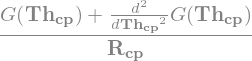

In [4]:
# Laplacian of psi
lapl_psi1 = sp.simplify(divergence(gradient(psi1)))
lapl_psi1

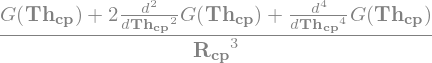

In [5]:
# Biharmonic (bi-Laplacian) of psi
biharm_psi1 = sp.simplify(divergence(gradient(divergence(gradient(psi1)))))
biharm_psi1

In [6]:
# general solution of the resulting ODE,
# substituting the coordinate cp.Th with a generic variable theta
# to allow us to keep working with dsolve
theta = sp.symbols('theta')
sp.dsolve((biharm_psi1*cp.R**3).subs(cp.Th, theta))

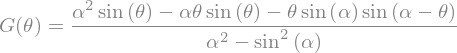

In [7]:
# solution of the resulting ODE with our BCs (dsolve calls them ics...),
# again, substituting the coordinate cp.Th with a generic variable theta
alpha = sp.symbols('alpha')
ics1 = {G1.subs(cp.Th, theta).diff(theta).subs(theta, 0): 1,
        G1.subs(cp.Th, theta).subs(theta, 0): 0,
        G1.subs(cp.Th, theta).diff(theta).subs(theta, alpha): 0,
        G1.subs(cp.Th, theta).subs(theta, alpha): 0}
G1sol = sp.dsolve((biharm_psi1*cp.R**3).subs(cp.Th, theta),
                  ics=ics1).simplify()
G1sol

In [8]:
# confirm this solution is algebraically identical to Panton's
G1panton = 1/(alpha**2 - sp.sin(alpha)**2) \
    * (alpha**2*sp.sin(cp.Th) - sp.sin(alpha)**2*cp.Th*sp.cos(cp.Th)
       + (sp.cos(alpha)*sp.sin(alpha) - alpha)*cp.Th*sp.sin(cp.Th))
(G1sol.rhs - G1panton.subs(cp.Th, theta)).simplify()

In [9]:
# create a lambdified version of psi for evaluation and plotting
psi_Taylor = sp.lambdify([cp.R, cp.Th, alpha], cp.R *
                         G1panton, modules=['numpy'])

v_Taylor = curl(cp.z*cp.R*G1panton)
# create a lambdified version of vr and vth for evaluation and plotting
v_Taylor_r_sym = sp.simplify(v_Taylor & cp.r)
v_Taylor_th_sym = sp.simplify(v_Taylor & cp.th)
v_Taylor_r = sp.lambdify([cp.R, cp.Th, alpha],
                         v_Taylor_r_sym, modules=['numpy'])
v_Taylor_th = sp.lambdify([cp.R, cp.Th, alpha],
                          v_Taylor_th_sym, modules=['numpy'])

## Visualization of the streamlines

In [10]:
def streamline_plot_func(α):
    # range, square domain
    xymax = 10
    x, y = np.meshgrid(np.linspace(0, xymax, num=500),
                       np.linspace(0, xymax, num=500))
    r = np.sqrt(x**2 + y**2)
    th = np.arctan2(y, x)

    fig, ax = plt.subplots()

    z = psi_Taylor(r, th, α*np.pi/180)

    # remove any streamlines outside the wedge 0 <= theta <= alpha
    z[np.where(np.abs(th) > α*np.pi/180)] = 0

    strm = ax.contour(x, y, z,
                      # note this function takes linewidthS, plural...
                      linewidths=2,
                      cmap=colormaps['YlGnBu_r'])

    ax.clabel(strm, inline=True, fontsize=10)

    ax.set_xlabel('$x^*$')
    ax.set_ylabel('$y^*$')

    ax.grid(alpha=0.5, linestyle='dotted')

    plt.show()

First, a static plot.

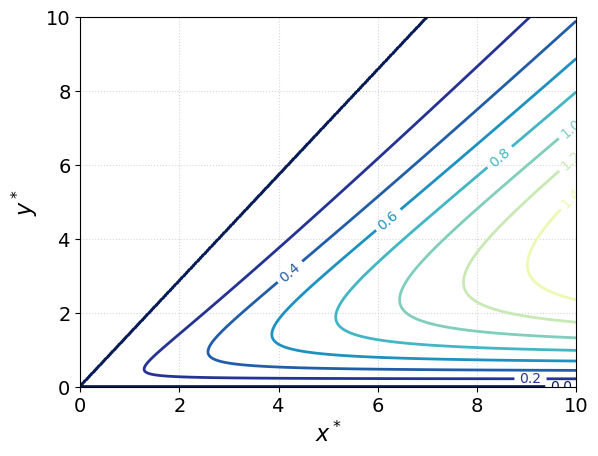

In [11]:
streamline_plot_func(55)

In [12]:
# alpha on the slider is in degrees
interact(streamline_plot_func,
         α=widgets.FloatSlider(value=55, min=10, max=85, step=5, description='Angle α'))

<function __main__.streamline_plot_func(α)>

In [13]:
def stream_plot_func(α):
    # range, square domain
    xymax = 10
    x, y = np.meshgrid(np.linspace(0, xymax, num=500),
                       np.linspace(0, xymax, num=500))
    r = np.sqrt(x**2 + y**2)
    th = np.arctan2(y, x)
    # remove any streamlines outside the wedge 0 <= theta <= alpha
    th[np.where(np.abs(th) > α*np.pi/180)] = np.nan

    vx = v_Taylor_r(r, th, α*np.pi/180)*np.cos(th) \
        - v_Taylor_th(r, th, α*np.pi/180)*np.sin(th)
    vy = v_Taylor_r(r, th, α*np.pi/180)*np.sin(th) \
        + v_Taylor_th(r, th, α*np.pi/180)*np.cos(th)

    fig, ax = plt.subplots()

    cols = np.sqrt(vx**2+vy**2)
    strm = ax.streamplot(x, y, vx, vy,
                         color=cols, linewidth=2,
                         cmap='YlGnBu_r')

    # plot the boundaries, theta = 0, alpha
    ax.plot(x[0, :], np.tan(α*np.pi/180)*x[0, :], color='k', linewidth=3)
    ax.plot(x[0, :], 0*x[0, :], color='k', linewidth=3)

    ax.set_xlabel('$x^*$')
    ax.set_xlim(0, xymax)
    ax.set_ylabel('$y^*$')
    ax.set_ylim(-0.01, xymax)

    fig.colorbar(strm.lines, label=r'$\sqrt{(v_x^*)^2+(v_y^*)^2}$')

    ax.grid(alpha=0.5, linestyle='dotted')

    plt.show()

First, a static plot.

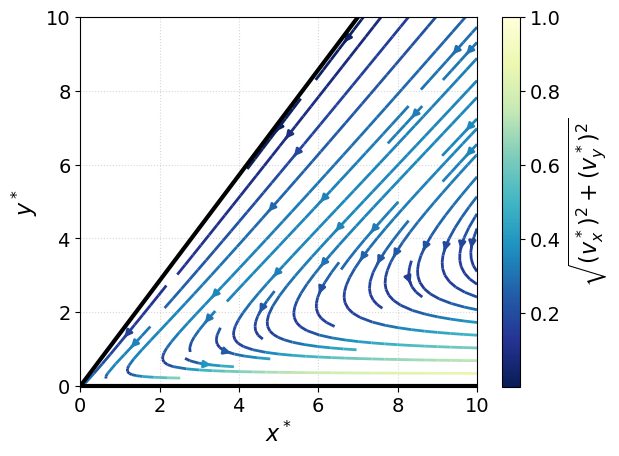

In [14]:
stream_plot_func(55)

In [15]:
# alpha on the slider is in degrees
interact(stream_plot_func,
         α=widgets.FloatSlider(value=55, min=10, max=85, step=5, description='Angle α'))

<function __main__.stream_plot_func(α)>

# MOFFATT'S EDDIES

## Solution for the streamfunction

The solution to [Moffatt's problem](https://www.cambridge.org/core/journals/journal-of-fluid-mechanics/article/abs/viscous-and-resistive-eddies-near-a-sharp-corner/6F1FC07C3D919ADB9CE0FF75180FF1D2), once again in terms of a dimensionless streamfunction, is
$$
  \psi(r,\theta) = r^{n+1} G(\theta;n),
$$
where
$$
  G(\theta;n) = A \cos[(n+1)\theta] + B \sin[(n+1)\theta] + C \cos[(n-1)\theta] + D \sin[(n-1)\theta],
$$
subject to
\begin{align*}
  G(\theta = \pm\alpha;n) &= 0,\\
  G'(\theta = \pm\alpha;n) &= 0.\\
\end{align*}

The wedge's total angle is now $2\alpha$, so the domain we solve the problem is $\{(r,\theta) \;|\; r>0, \;-\alpha \le \theta \le +\alpha\}$.

By symmetry, the conditions at $\theta=+\alpha$ yield the same relations as at $\theta=-\alpha$. 

The $\theta\mapsto-\theta$ symmetry also requires that $B = D = 0$, leaving only the cosine terms. 

Note that the way to enforce the $\theta=-\alpha$ on _both_ G and G' is to require that $G'(0) = G'''(0)$ (the vanishing derivative of each at $\theta=0$ enforces the symmetry).

We can use SymPy to check this solution.

In [16]:
# create a planar polar coordinate system,
# same as cylindrical if we ignore z
c = CoordSys3D('c')
cp = c.create_new('cp', transformation='cylindrical',
                  vector_names=("r", "th", "z"),
                  variable_names=("R", "Th", "Z"))

# print change of coordinates formula for our reference
cp.transformation_to_parent()

In [17]:
# define the streamfunction for Moffatt's problem
n = sp.symbols('n', real=True)  # make n real...for now
G2 = sp.Function('G')(cp.Th)
psi2 = cp.R**(n+1)*G2

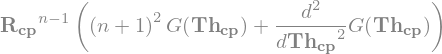

In [18]:
# Laplacian of psi
lapl_psi2 = sp.simplify(divergence(gradient(psi2)))
lapl_psi2

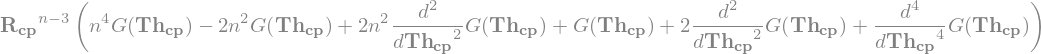

In [19]:
# Biharmonic (bi-Laplacian) of psi
biharm_psi2 = sp.simplify(divergence(gradient(divergence(gradient(psi2)))))
biharm_psi2

In [20]:
# solution of the resulting ODE with our **symmetry** BCs,
# again, substituting the coordinate cp.Th with a generic variable theta
symmetry_bcs = {G2.subs(cp.Th, theta).diff(theta, 1).subs(theta, 0): 0,
                G2.subs(cp.Th, theta).diff(theta, 3).subs(theta, 0): 0}
G2sol = sp.dsolve((biharm_psi2*cp.R**(n-3)).subs(cp.Th, theta), ics=symmetry_bcs)
G2sol

It didn't fully simplify the square roots, which factor, so we push it along.

In [21]:
G2sol_simp = G2sol.subs(-n**2+2*n-1, sp.factor(-n**2+2*n-1))
G2sol_simp = G2sol_simp.subs(n**2+2*n+1, sp.factor(n**2+2*n+1))
G2sol_simp = G2sol_simp.subs(sp.Abs(n-1), n-1)
G2sol_simp = G2sol_simp.subs(sp.Abs(n+1), n+1)
G2sol_simp = G2sol_simp.rhs.rewrite(sp.cos).trigsimp()
G2sol_simp

Apparently, we still need to redefine $C_2$ and $C_4$ to absorb the factors of $2$.

In [22]:
# confirm this solution is algebraically identical to Moffatt's
C2, C4 = sp.symbols('C2, C4')
G2sol = G2sol_simp.subs(C2*2, C2).simplify().subs(C4*2, C4)
G2moffatt = C2*sp.cos((n+1)*cp.Th) + C4*sp.cos((n-1)*cp.Th)
sp.simplify(sp.Eq(G2sol, G2moffatt.subs(cp.Th, theta)))

In [23]:
# define the streamfunction for Moffatt's problem
alpha = sp.symbols('alpha', real=True)
A, C = sp.symbols('A, C')
psi2 = cp.R**(n+1)*(A*sp.cos((n+1)*cp.Th) + C*sp.cos((n-1)*cp.Th))

# create a lambdified version of psi for evaluation and plotting
psi_Moffatt = sp.lambdify([cp.R, cp.Th, n, alpha],
                          psi2.subs(A, -sp.cos((n-1)*alpha) / sp.cos((n+1)*alpha)).subs(C, 1),
                          modules=['numpy'])

## Possible solutions for $n$

The remaining 2 _homogeneous_ BCs on $G$ lead to a linear system:

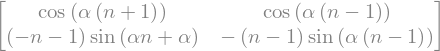

In [24]:
# build matrix for system of equations enforcing the BCs
# requires some hacking to simplify right
BC1 = G2sol.subs(theta, alpha).simplify()
BC2 = G2sol.diff(theta).subs(theta, alpha).simplify()
C2, C4 = sp.symbols('C2, C4')
system_matrix = sp.Matrix([[BC1.coeff(C2).rewrite(sp.cos).trigsimp(), BC1.coeff(C4)],
                           [BC2.coeff(C2).rewrite(sp.cos).trigsimp(), BC2.coeff(C4)]])
system_matrix

The only solution of this system is the trivial solution $A=C=0$, _unless_ the determinant of the linear system is zero (singular matrix), that is:
$$
  \left|\begin{matrix} \cos[(n+1)\alpha] & \cos[(n-1)\alpha] & \\ -(n+1)\sin[(n+1)\alpha] & -(n-1)\sin[(n-1)\alpha] \end{matrix} \right| = 0.
$$

Using SymPy, we can simplify this equation:

In [25]:
solv_cond = system_matrix.det().trigsimp()
solv_cond

So, the condition for having nontrivial $A$, $C$ solutions is
$$
  n\sin(2\alpha) + \sin(2n\alpha) = 0.
$$
Since $n$ is undetermined, perhaps we can make this happen (or at least for some values of $\alpha$).

We can plot the left-hand side of the condition above as a function of $n$ for different values of $2\alpha$ to see if it has real solutions (zero crossings).

In [26]:
# create a lambdified version for evaluation and plotting
nl_eq_lhs = sp.lambdify([n, alpha], solv_cond, modules=['numpy'])

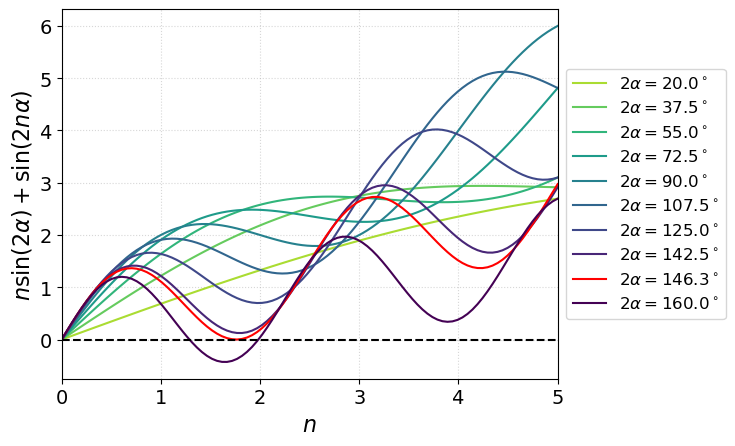

In [27]:
plot_alpha = np.linspace(10, 80, 9)
alpha_crit = 73.15
nplot = np.linspace(0, 5, 100)

fig, ax = plt.subplots()

# sequential colormap with gradient that looks nice, also try 'cool' or 'summer'
# https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential
cmap = colormaps['viridis_r']

for angle in plot_alpha:
    # plot the critical angle in red in the correct order wrt to the others
    if angle >= alpha_crit:
        ax.plot(nplot, nl_eq_lhs(nplot, alpha_crit*np.pi/180),
                color='red',
                label=r'$2\alpha=146.3^\circ$')
    ax.plot(nplot, nl_eq_lhs(nplot, angle*np.pi/180),
            color=cmap(angle/plot_alpha.max()),
            label=rf'$2\alpha={2*angle:.1f}^\circ$')

ax.plot(nplot, 0*nplot, ls='dashed', color='black')

ax.set_xlabel('$n$')
ax.set_ylabel(r'$n\sin(2\alpha) + \sin(2n\alpha)$')

ax.set_xlim(nplot.min(), nplot.max())

# move legend off the plot because it is too long
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# show a grid to make it easier to see where the y=0 interface is
ax.grid(alpha=0.5, linestyle='dotted')

plt.show()

Indeed, as claimed in papers & books, no real solutions exist for $2\alpha\lesssim146.3^\circ$.

Now, can we find the solutions for $n$, whether real or complex? The real case is easy, but the complex case is not; numerical rootfinders are usually only good for real solutions.

Either way, following Moffatt, we set $n = p + i q$, which transforms the single transcendental equation for complex $n$ into two real ones (by taking real and imaginary parts). Let's use SymPy again:


In [28]:
p, q = sp.symbols('p, q', real='True')
solv_cond = n*sp.sin(2*alpha)+sp.sin(2*alpha*n)
peq = sp.Eq(sp.re(solv_cond.subs(n, p+sp.I*q).expand(complex=True)).trigsimp(), 0)
qeq = sp.Eq(sp.im(solv_cond.subs(n, p+sp.I*q).expand(complex=True)).trigsimp(), 0)
display(peq)
display(qeq)

So, the problem is reduced to finding roots (solutions $p$ and $q$) of the latter **two** coupled equations, given $2\alpha$.


In [29]:
# pick an angle < 73.15 deg, for example 28.5 deg
plot_alpha = 28.5/2*np.pi/180

# lambdify nonlinear eqs for p and q for numerical use
# group arguments in conveniently for scipy optimize
nl_eq_lhs_n = sp.lambdify([[p, q], alpha], [qeq.lhs, peq.lhs], modules=['numpy'])

# solve the nonlinear eqs for p and q
# local minima exist; initial guess x0 can be important
# based on Moffatt's Table I, we try p0 = 4/(2*alpha), q0 = 2/(2*alpha)
pq0 = [4/(2*plot_alpha), 2/(2*plot_alpha)]
nsol = op.root(nl_eq_lhs_n, x0=pq0, args=(plot_alpha, ), tol=1e-12)

print(nsol)
# nsol.x contains the array with the solution for p and q

 message: The solution converged.
 success: True
  status: 1
     fun: [-1.776e-15 -8.882e-16]
       x: [ 8.485e+00  4.434e+00]
  method: hybr
    nfev: 14
    fjac: [[-9.802e-01  1.978e-01]
           [-1.978e-01 -9.802e-01]]
       r: [-2.032e+00  1.980e-01  2.080e+00]
     qtf: [ 2.727e-14 -4.113e-13]


To validate this code (see also the manual for [`scipy.optimize.OptimizeResult`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.OptimizeResult.html#scipy.optimize.OptimizeResult) to learn what the output above means), we can reproduce some of the results from Table I of [Moffatt's paper](https://www.cambridge.org/core/journals/journal-of-fluid-mechanics/article/abs/viscous-and-resistive-eddies-near-a-sharp-corner/6F1FC07C3D919ADB9CE0FF75180FF1D2). For example, $p\approx 2.27$, $q\approx 0.76$ for $2\alpha=110^\circ$.

For the configuration later realized in experiments by [Taneda](https://journals.jps.jp/doi/abs/10.1143/JPSJ.46.1935?journalCode=jpsj), $2\alpha = 28.5^\circ$. [Eggers & Fontelos](https://www.cambridge.org/core/books/singularities-formation-structure-and-propagation/F239878E447F48C5603A0F70AC103AA5) report $p\approx 8.49$, $q \approx 4.43$ for this case.

## Visualization of the streamlines

To see the flow pattern, we can solve for $A = -C \cos[(n-1)\alpha]/\cos[(n+1)\alpha]$, from $G(\theta=\pm\alpha;n)=0$, and take $C=1$ without loss of generality. Then, we substitute the numerical value of $n$ found above (possibly complex)  for the chosen angle $\alpha$.

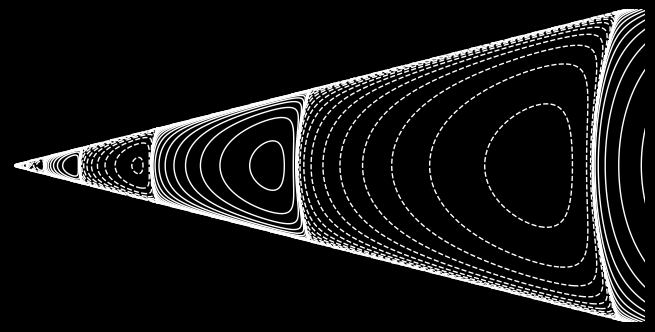

In [30]:
# custom rectangular domain, longer in x for smaller angles
xymax = 1
x, y = np.meshgrid(np.linspace(0, xymax/np.sin(plot_alpha), num=1000),
                   np.linspace(-xymax, xymax, num=1000))

r = np.sqrt(x**2 + y**2)
th = np.arctan2(y, x)

plt.style.use('dark_background')  # !
fig, ax = plt.subplots()

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
# to mantain angles in the plot
ax.set_aspect('equal', 'box')

# take the real part, important for complex c
z = np.real(psi_Moffatt(r, th, nsol.x[0]+1j*nsol.x[1], plot_alpha))

# remove any streamlines outside the wedge -alpha <= theta <= alpha
z[np.where(np.abs(th) > plot_alpha)] = np.nan

# due to the exponentially damped nature of the vortices,
# we need logarithmic spacing of the contour levels
loglevels = np.logspace(-15, 5, 50)
consts = np.concatenate((-np.flip(loglevels), loglevels))

# we will not use colors or labelclips4ss because of the logarithmic spacing
strm = ax.contour(x, y, z, consts,
                  linewidths=1, colors='white')

ax.axis("off")
fig.set_size_inches(8.2, 5)
plt.style.use('default')         # !

Comparison to Taneda's photograph (also reproduced in [Van Dyke's _An Album of Fluid Motion_](https://drive.google.com/file/d/0B5UvitjuXx-bVWdoMFQxUXlZek0/view?resourcekey=0-6l7d0NYe7FY8muhx8pCL8A)).

![Taneda's photograph of Moffatt eddies. Two flat plates meet at a sharp corner at the left of the frame, forming a narrow wedge that opens to the right; the fluid between them is lit so the streamlines appear as fine white lines. A sequence of counter-rotating eddies fills the wedge, each one nearer the corner markedly smaller and fainter than the last, so the pattern appears to fade out before reaching the tip. Two eddy centers are clearly resolved and a third is only faintly visible near the corner.](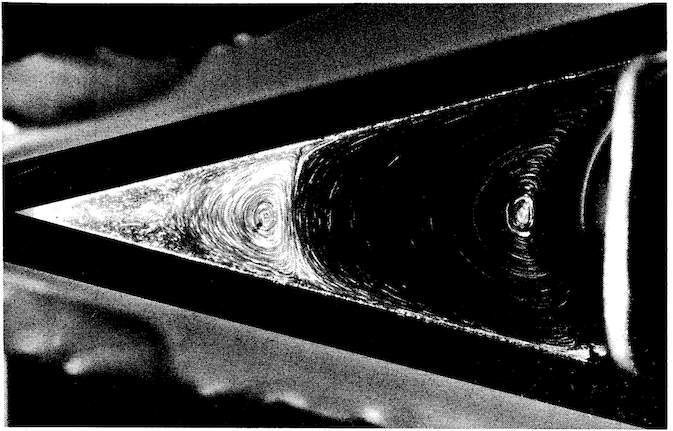)